<a href="https://colab.research.google.com/github/Sersan534/Pruebas-IA/blob/main/Modulo_2/2_3_1_2_Maneras_de_Programar_a_una_Red_Neuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3 Maneras de Programar a una Red Neuronal - DOTCSV

## Código inicial

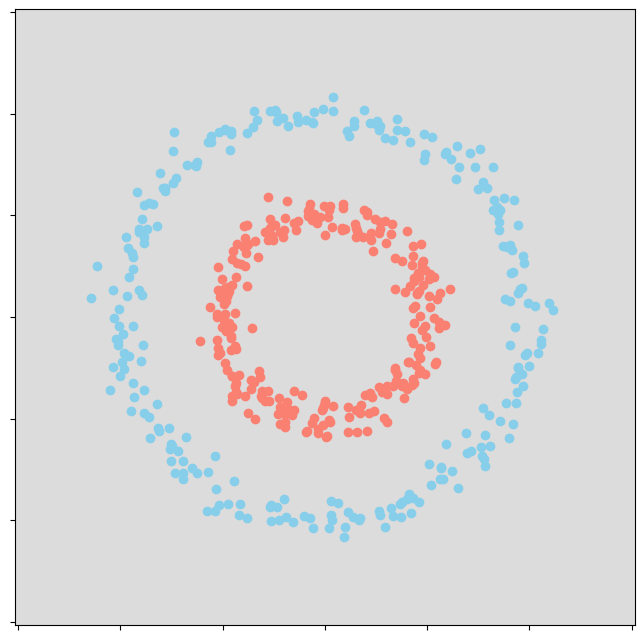

In [5]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

# Creamos nuestros datos artificiales, donde buscaremos clasificar
# dos anillos concéntricos de datos.
X, Y = make_circles(n_samples=500, factor=0.5, noise=0.05)

# Resolución del mapa de predicción.
res = 100

# Coordendadas del mapa de predicción.
_x0 = np.linspace(-1.5, 1.5, res)
_x1 = np.linspace(-1.5, 1.5, res)

# Input con cada combo de coordenadas del mapa de predicción.
_pX = np.array(np.meshgrid(_x0, _x1)).T.reshape(-1, 2)

# Objeto vacio a 0.5 del mapa de predicción.
_pY = np.zeros((res, res)) + 0.5

# Visualización del mapa de predicción.
plt.figure(figsize=(8, 8))
plt.pcolormesh(_x0, _x1, _pY, cmap="coolwarm", vmin=0, vmax=1)

# Visualización de la nube de datos.
plt.scatter(X[Y == 0,0], X[Y == 0,1], c="skyblue")
plt.scatter(X[Y == 1,0], X[Y == 1,1], c="salmon")

plt.tick_params(labelbottom=False, labelleft=False)

## Tensorflow

Step 0 / 1000 - Loss =  0.367093 - Acc = 0.566
Step 25 / 1000 - Loss =  0.29946807 - Acc = 0.644
Step 50 / 1000 - Loss =  0.27776566 - Acc = 0.71
Step 75 / 1000 - Loss =  0.26354074 - Acc = 0.73
Step 100 / 1000 - Loss =  0.25248498 - Acc = 0.742
Step 125 / 1000 - Loss =  0.24329005 - Acc = 0.758
Step 150 / 1000 - Loss =  0.23497036 - Acc = 0.768
Step 175 / 1000 - Loss =  0.22685532 - Acc = 0.772
Step 200 / 1000 - Loss =  0.21833502 - Acc = 0.782
Step 225 / 1000 - Loss =  0.20863208 - Acc = 0.786
Step 250 / 1000 - Loss =  0.19625741 - Acc = 0.794
Step 275 / 1000 - Loss =  0.18011016 - Acc = 0.804
Step 300 / 1000 - Loss =  0.16287784 - Acc = 0.814
Step 325 / 1000 - Loss =  0.14488034 - Acc = 0.822
Step 350 / 1000 - Loss =  0.13041443 - Acc = 0.832
Step 375 / 1000 - Loss =  0.11769285 - Acc = 0.842
Step 400 / 1000 - Loss =  0.105717294 - Acc = 0.856
Step 425 / 1000 - Loss =  0.09442473 - Acc = 0.858
Step 450 / 1000 - Loss =  0.08407778 - Acc = 0.862
Step 475 / 1000 - Loss =  0.074469194 -

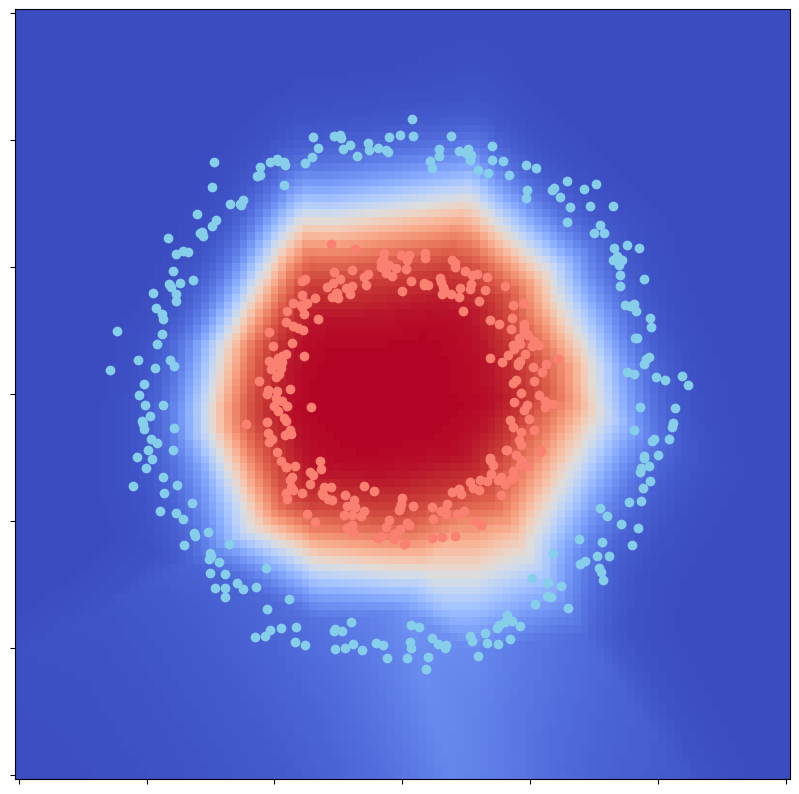

In [10]:
import tensorflow as tf # es de diferenciacion automática, igual que pytorch. Calculan automaticamente las derivadas.

# Desactivar eager execution para compatibilidad con TensorFlow 1.x
tf.compat.v1.disable_eager_execution()

from matplotlib import animation
from IPython.core.display import display, HTML

# Definimos los puntos de entrada de la red, para la matriz X e Y.
iX = tf.compat.v1.placeholder('float', shape=[None, X.shape[1]])
iY = tf.compat.v1.placeholder('float', shape=[None])

lr = 0.01           # learning rate
nn = [2, 16, 8, 1]  # número de neuronas por capa.

# Capa 1
W1 = tf.compat.v1.Variable(tf.compat.v1.random_normal([nn[0], nn[1]]), name='Weights_1')#0 es la entrada, es decir que son 2 y 1 es el numero de neuronas de la primera capa, 16
b1 = tf.compat.v1.Variable(tf.compat.v1.random_normal([nn[1]]), name='bias_1')

l1 = tf.nn.relu(tf.add(tf.matmul(iX, W1), b1))

# Capa 2
W2 = tf.compat.v1.Variable(tf.compat.v1.random_normal([nn[1], nn[2]]), name='Weights_2')
b2 = tf.compat.v1.Variable(tf.compat.v1.random_normal([nn[2]]), name='bias_2')

l2 = tf.nn.relu(tf.add(tf.matmul(l1, W2), b2))

# Capa 3
W3 = tf.compat.v1.Variable(tf.compat.v1.random_normal([nn[2], nn[3]]), name='Weights_3')
b3 = tf.compat.v1.Variable(tf.compat.v1.random_normal([nn[3]]), name='bias_3')

# Vector de predicciones de Y.
pY = tf.nn.sigmoid(tf.add(tf.matmul(l2, W3), b3))[:, 0] #no se usa relu y se usa la version sigmoide en la ultima capa


# Evaluación de las predicciones.
loss = tf.compat.v1.losses.mean_squared_error(pY, iY) #es el error cuad medio entre py (lo que sale de la red neuronal, predicciones) y yi(el valor real de las variables)

# Definimos al optimizador de la red, para que minimice el error.
optimizer = tf.compat.v1.train.GradientDescentOptimizer(learning_rate=0.05).minimize(loss)#añadimos un optimizador dentro de trarin

n_steps = 1000 # Número de ciclos de entrenamiento.

iPY = [] # Aquí guardaremos la evolución de la predicción, para la animación.

with tf.compat.v1.Session() as sess:

  # Inicializamos todos los parámetros de la red, las matrices W y b.
  sess.run(tf.compat.v1.global_variables_initializer())

  # Iteramos n pases de entrenamiento.
  for step in range(n_steps):

    # Evaluamos al optimizador, a la función de coste y al tensor de salida pY.
    # La evaluación del optimizer producirá el entrenamiento de la red.
    _, _loss, _pY = sess.run([optimizer, loss, pY], feed_dict={ iX : X, iY : Y }) #queremos que corra la funcion optimizer con el error y con los datos que hemos predicho

    # Cada 25 iteraciones, imprimimos métricas.
    if step % 25 == 0:

      # Cálculo del accuracy.
      acc = np.mean(np.round(_pY) == Y)

      # Impresión de métricas.
      print('Step', step, '/', n_steps, '- Loss = ', _loss, '- Acc =', acc)

      # Obtenemos predicciones para cada punto de nuestro mapa de predicción _pX.
      _pY = sess.run(pY, feed_dict={ iX : _pX }).reshape((res, res))

      # Y lo guardamos para visualizar la animación.
      iPY.append(_pY)


# ----- CÓDIGO ANIMACIÓN ----- #

ims = []

fig = plt.figure(figsize=(10, 10))

print("--- Generando animación ---")

for fr in range(len(iPY)):

  im = plt.pcolormesh(_x0, _x1, iPY[fr], cmap="coolwarm", animated=True)

  # Visualización de la nube de datos.
  plt.scatter(X[Y == 0,0], X[Y == 0,1], c="skyblue")
  plt.scatter(X[Y == 1,0], X[Y == 1,1], c="salmon")

  # plt.title("Resultado Clasificación")
  plt.tick_params(labelbottom=False, labelleft=False)

  ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)

HTML(ani.to_html5_video())

## Keras

In [41]:
import tensorflow as tf
import tensorflow.keras as kr

tf.compat.v1.enable_eager_execution()


from IPython.core.display import display, HTML


lr = 0.01           # learning rate
nn = [2, 16, 8, 1]  # número de neuronas por capa.


# Creamos el objeto que contendrá a nuestra red neuronal, como
# secuencia de capas.
model = kr.Sequential()

# Añadimos la capa de entrada explícitamente
model.add(kr.Input(shape=(nn[0],)))
# Añadimos la primera capa densa
model.add(kr.layers.Dense(nn[1], activation='relu'))

# Añadimos la capa 2
model.add(kr.layers.Dense(nn[2], activation='relu'))

# Añadimos la capa 3
model.add(kr.layers.Dense(nn[3], activation='sigmoid'))

# Compilamos el modelo, definiendo la función de coste y el optimizador.
model.compile(loss='mse', optimizer=kr.optimizers.SGD(learning_rate=0.05), metrics=['acc'])

# Y entrenamos al modelo. Los callbacks
model.fit(X, Y, epochs=100)

ValueError: tf.enable_eager_execution must be called at program startup.

## Sklearn

In [18]:
import sklearn as sk
import sklearn.neural_network

from IPython.core.display import display, HTML


lr = 0.01           # learning rate
nn = [2, 16, 8, 1]  # número de neuronas por capa.

# Creamos el objeto del modelo de red neuronal multicapa.
clf = sk.neural_network.MLPRegressor(solver='sgd',
                                     learning_rate_init=lr,
                                     hidden_layer_sizes=tuple(nn[1:]), #el tamaño de las capas ocultas, no le pasamos la primera
                                     verbose=True,
                                     n_iter_no_change=1000,
                                     batch_size = 64)


# Y lo entrenamos con nuestro datos.
clf.fit(X, Y)

Iteration 1, loss = 0.50854765
Iteration 2, loss = 0.22367954
Iteration 3, loss = 0.15297872
Iteration 4, loss = 0.13574858
Iteration 5, loss = 0.12933172
Iteration 6, loss = 0.12593967
Iteration 7, loss = 0.12310374
Iteration 8, loss = 0.11860528
Iteration 9, loss = 0.11633797
Iteration 10, loss = 0.11352751
Iteration 11, loss = 0.11151701
Iteration 12, loss = 0.10880110
Iteration 13, loss = 0.10624965
Iteration 14, loss = 0.10503495
Iteration 15, loss = 0.10264047
Iteration 16, loss = 0.10052061
Iteration 17, loss = 0.09860981
Iteration 18, loss = 0.09671144
Iteration 19, loss = 0.09454712
Iteration 20, loss = 0.09231473
Iteration 21, loss = 0.09021817
Iteration 22, loss = 0.08715093
Iteration 23, loss = 0.08423117
Iteration 24, loss = 0.08132268
Iteration 25, loss = 0.07778181
Iteration 26, loss = 0.07427442
Iteration 27, loss = 0.07055505
Iteration 28, loss = 0.06673444
Iteration 29, loss = 0.06208668
Iteration 30, loss = 0.05756438
Iteration 31, loss = 0.05339340
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(batch_size=64, hidden_layer_sizes=(16, 8, 1),
             learning_rate_init=0.01, n_iter_no_change=1000, solver='sgd',
             verbose=True)